In [215]:
import gym
from gym import spaces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy

In [216]:
# 데이터 준비
def load_data(path):
    data = pd.read_csv(path)  # 주식 데이터를 여기에 로드합니다.
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)
    return data

In [217]:
data = load_data('./datas/data_with_indicator.csv')

In [218]:
# 환경 설정
class StockTradingEnv(gym.Env):
    metadata = {'render.modes': ['human']}
    
    def __init__(self, df):
        super(StockTradingEnv, self).__init__()

        self.df = df
        self.current_step = 0
        self.window_size = 10
        self.inventory = []
        self.total_profit = 0
        self.done = False
        self.actions = []
        
        # Actions: 0 = Hold, 1 = Buy, 2 = Sell
        self.action_space = spaces.Discrete(3)
        
        # Observation: [window_size previous prices, inventory, total profit]
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window_size + 2,), dtype=np.float32)

    def reset(self):
        self.current_step = self.window_size
        self.inventory = []
        self.total_profit = 0
        self.done = False
        self.actions = []
        return self._next_observation()

    def _next_observation(self):
        end = self.current_step
        start = end - self.window_size
        obs = self.df['Close'].values[start:end].tolist()
        obs = [(obs[i] / obs[0]) - 1 for i in range(len(obs))]  # Normalize to the first value
        obs.append(len(self.inventory))  # Add inventory count
        obs.append(self.total_profit)    # Add total profit
        return np.array(obs, dtype=np.float32)

    def step(self, action):
        reward = 0

        if action == 1:  # Buy
            self.inventory.append(self.df['Close'].iloc[self.current_step])
        elif action == 2 and self.inventory:  # Sell
            bought_price = self.inventory.pop(0)
            reward = self.df['Close'].iloc[self.current_step] - bought_price
            self.total_profit += reward

        self.actions.append(action)  # Record the action

        self.current_step += 1

        if self.current_step >= len(self.df) - 1:
            self.done = True

        obs = self._next_observation()
        return obs, reward, self.done, {}

    def render(self, mode='human', close=False):
        print(f'Step: {self.current_step}, Total Profit: {self.total_profit}')

In [219]:
# 학습 및 평가를 위한 환경 래핑
env = StockTradingEnv(data)
vec_env = DummyVecEnv([lambda: env])

/Users/seokmin/anaconda3/envs/StockLearning/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [220]:
model = PPO('MlpPolicy', vec_env, verbose=1)

Using cpu device


In [221]:
model.learn(total_timesteps=10000)

-----------------------------
| time/              |      |
|    fps             | 8192 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
---------------------------------------
| time/                   |           |
|    fps                  | 4909      |
|    iterations           | 2         |
|    time_elapsed         | 0         |
|    total_timesteps      | 4096      |
| train/                  |           |
|    approx_kl            | 0.0       |
|    clip_fraction        | 0         |
|    clip_range           | 0.2       |
|    entropy_loss         | -1.1      |
|    explained_variance   | 1.19e-07  |
|    learning_rate        | 0.0003    |
|    loss                 | 2.66e+14  |
|    n_updates            | 10        |
|    policy_gradient_loss | -6.99e-08 |
|    value_loss           | 6.52e+14  |
---------------------------------------
---------------------------------------
| time/                   |   

In [222]:
# # 6. 모델 평가
# mean_reward, std_reward = evaluate_policy(model, vec_env, n_eval_episodes=10000)
# print(f"Mean reward: {mean_reward}, Std reward: {std_reward}")

In [223]:
# 7. 모델 저장
model.save("./model/ppo_stock_trading")

In [224]:
# 트레이딩 결과 시각화 함수
def plot_trading(df, actions, window_size):
    plt.figure(figsize=(15,6))
    plt.plot(df.index, df['Close'], label='Price')

    buy_signals = np.where(actions == 1)[0]
    sell_signals = np.where(actions == 2)[0]

    plt.plot(df.index[buy_signals + window_size], df['Close'].values[buy_signals + window_size], marker='^', color='g', linestyle='none', label='Buy')
    plt.plot(df.index[sell_signals + window_size], df['Close'].values[sell_signals + window_size], marker='v', color='r', linestyle='none', label='Sell')

    plt.legend()
    plt.show()


In [225]:
# 원래 환경 객체를 가져와 시각화 준비
env.reset()

array([0.        , 0.01044843, 0.01732179, 0.0220753 , 0.02295722,
       0.01329088, 0.01347661, 0.021504  , 0.01624928, 0.03139725,
       0.        , 0.        ], dtype=float32)

In [226]:
test_data = load_data('./datas/test_data_with_indicator.csv')

In [227]:
# 모델이 환경을 탐험하면서 데이터를 수집하도록 시뮬레이션 실행
obs = env.reset()
for _ in range(len(data) - env.window_size - 1):
    action, _ = model.predict(np.array(obs))
    obs, rewards, done, info = env.step(action)
    if done:
        break

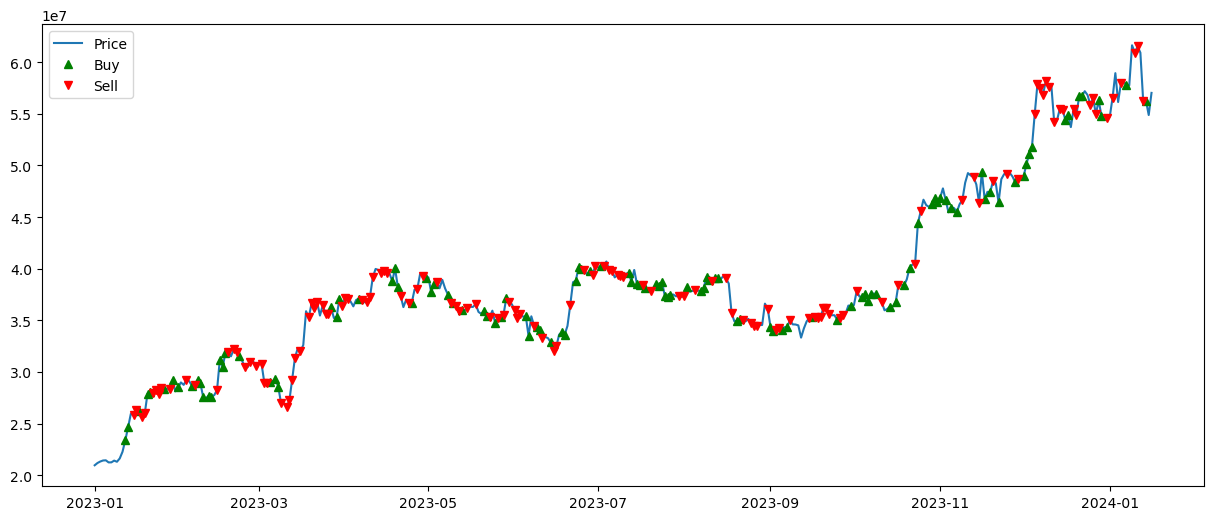

In [228]:
# 시각화
plot_trading(data, np.array(env.actions), env.window_size)

In [229]:
# 총 수익 출력
print(f"Total Profit: {env.total_profit}")

Total Profit: 216584404.0
